# Laboratorio 2 — Complejidad y búsqueda de hiperparámetros

**Estudiantes:** Danna Garcia (202320823), Julian Ferreira (202012068)

**Caso AlpesPlanck.** Continuando el Lab 1, se exploran enfoques de modelado más flexibles (regresión polinomial y regularizada) para estimar `temp_max_manana`, evaluando su desempeño y estabilidad mediante validación cruzada, búsqueda sistemática de hiperparámetros e intervalos de confianza por bootstrapping.

## 1. Importación de librerías y carga de datos

Se reutiliza el conjunto de datos crudo del Laboratorio 1 (`Datos Lab 1.csv`). El énfasis de este laboratorio no está en la exploración ni el procesamiento de los datos (ya cubierto en el Lab 1), sino en el modelado, la validación y el análisis del desempeño predictivo.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample

RUTA_DATOS = 'data/Datos Lab 1.csv'
OBJETIVO = 'temp_max_manana'

datos_originales = pd.read_csv(RUTA_DATOS)
datos_originales.head()


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


## 2. Partición de los datos

Se descartan duplicados y filas sin etiqueta (`temp_max_manana`), tal como se justificó en el Lab 1, y se separa en entrenamiento y prueba con la misma semilla (`random_state=42`, `test_size=0.25`) para mantener comparabilidad entre laboratorios.

In [5]:
datos = datos_originales.drop_duplicates().dropna(subset=[OBJETIVO]).copy()

X = datos.drop(columns=[OBJETIVO, 'fecha'])
y = datos[OBJETIVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'Entrenamiento: {X_train.shape[0]} filas')
print(f'Prueba: {X_test.shape[0]} filas')


Entrenamiento: 1857 filas
Prueba: 620 filas


## 3. Limpieza de datos (recuperada del Lab 1)

Se recuperan tal cual las funciones de limpieza ya justificadas en el Lab 1: `limpiar_valores_numericos` convierte en ausentes los valores físicamente imposibles (rangos definidos en `RANGOS_VALIDOS`), y `limpiar_predictoras` además normaliza las variantes de escritura de las variables categóricas (`estacion_anio`, `mes`, `sector_viento`). Se empaquetan en `limpiador`, un `FunctionTransformer` que se usará como primer paso dentro de cada pipeline de modelado, para que la limpieza se aplique de forma consistente al entrenar y al predecir.

In [6]:
RANGOS_VALIDOS = {
    'presion_media': (900, 1100), 'presion_min': (900, 1100), 'presion_max': (900, 1100),
    'presion_desv': (0, 100), 'humedad_media': (0, 100), 'humedad_min': (0, 100),
    'humedad_max': (0, 100), 'humedad_desv': (0, 100), 'viento_media': (0, 100),
    'viento_min': (0, 100), 'viento_max': (0, 100), 'viento_desv': (0, 100),
    'rafaga_media': (0, 100), 'rafaga_min': (0, 100), 'rafaga_max': (0, 100),
    'rafaga_desv': (0, 100), 'viento_norte': (-100, 100), 'viento_este': (-100, 100),
    'direccion_viento': (0, 360), 'registros_del_dia': (1, 144),
    'anio': (2003, 2015), 'dia_del_anio': (1, 366)
}

def limpiar_valores_numericos(dataframe):
    limpio = dataframe.copy()
    for columna, (minimo, maximo) in RANGOS_VALIDOS.items():
        limpio.loc[~limpio[columna].between(minimo, maximo), columna] = np.nan
    return limpio

MAPA_ESTACION = {
    'invierno': 'invierno', 'invernio': 'invierno', 'winter': 'invierno',
    'primavera': 'primavera', 'primav': 'primavera', 'primaveraa': 'primavera', 'spring': 'primavera',
    'verano': 'verano', 'berano': 'verano', 'verno': 'verano', 'summer': 'verano',
    'otono': 'otono', 'otoño': 'otono', 'autumn': 'otono', 'fall': 'otono'
}
MAPA_MES = {
    'jan': 'enero', 'january': 'enero', 'enero': 'enero',
    'feb': 'febrero', 'february': 'febrero', 'febrero': 'febrero',
    'mar': 'marzo', 'march': 'marzo', 'marzo': 'marzo',
    'apr': 'abril', 'april': 'abril', 'abril': 'abril',
    'may': 'mayo', 'mayo': 'mayo',
    'jun': 'junio', 'june': 'junio', 'junio': 'junio',
    'jul': 'julio', 'july': 'julio', 'julio': 'julio',
    'aug': 'agosto', 'august': 'agosto', 'agosto': 'agosto',
    'sep': 'septiembre', 'sept': 'septiembre', 'september': 'septiembre', 'septiembre': 'septiembre',
    'oct': 'octubre', 'october': 'octubre', 'octubre': 'octubre',
    'nov': 'noviembre', 'november': 'noviembre', 'noviembre': 'noviembre',
    'dec': 'diciembre', 'december': 'diciembre', 'diciembre': 'diciembre'
}
MAPA_SECTOR = {
    'n': 'N', 'north': 'N', 'norte': 'N',
    'ne': 'NE', 'northeast': 'NE', 'noreste': 'NE',
    'e': 'E', 'east': 'E', 'este': 'E',
    'se': 'SE', 'southeast': 'SE', 'sureste': 'SE',
    's': 'S', 'south': 'S', 'sur': 'S',
    'so': 'SO', 'southwest': 'SO', 'suroeste': 'SO',
    'o': 'O', 'west': 'O', 'oeste': 'O',
    'no': 'NO', 'northwest': 'NO', 'noroeste': 'NO'
}

def limpiar_predictoras(dataframe):
    limpio = limpiar_valores_numericos(dataframe)
    limpio['estacion_anio'] = limpio['estacion_anio'].str.strip().str.lower().map(MAPA_ESTACION)
    limpio['mes'] = limpio['mes'].str.strip().str.lower().map(MAPA_MES)
    limpio['sector_viento'] = limpio['sector_viento'].str.strip().str.lower().map(MAPA_SECTOR)
    return limpio

limpiador = FunctionTransformer(limpiar_predictoras, validate=False)

columnas_numericas = X.select_dtypes(include='number').columns.tolist()
columnas_categoricas = X.select_dtypes(include='object').columns.tolist()


## 4. Modelo de regresión polinomial de grado 2

Se construye un pipeline que, además de la limpieza, imputa y estandariza las variables numéricas, genera sus términos polinomiales de grado 2 (cuadrados y productos cruzados) con `PolynomialFeatures`, codifica las categóricas con one-hot, y ajusta una regresión lineal sobre ese conjunto ampliado de variables.

In [7]:
preparacion_numerica_poly = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2))
])

preparacion_categorica = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocesador_poly = ColumnTransformer(transformers=[
    ('numericas', preparacion_numerica_poly, columnas_numericas),
    ('categoricas', preparacion_categorica, columnas_categoricas)
])

pipeline_polinomial = Pipeline(steps=[
    ('limpieza', limpiador),
    ('preparacion', preprocesador_poly),
    ('modelo', LinearRegression())
])

pipeline_polinomial.fit(X_train, y_train)

num_coeficientes = len(pipeline_polinomial.named_steps['modelo'].coef_)
print('Número de coeficientes:', num_coeficientes)


Número de coeficientes: 300


El modelo pasó de tener ~22 coeficientes (regresión lineal simple del Lab 1) a 300, al incluir los términos cuadráticos y cruzados de las 22 variables numéricas más las categorías codificadas. Esta es la evidencia directa del aumento de complejidad del modelo.

### Validación en entrenamiento

In [8]:
pred_train_poly = pipeline_polinomial.predict(X_train)

print('------ Modelo polinomial grado 2 - Entrenamiento ------')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, pred_train_poly)):.3f}")
print(f"MAE: {mean_absolute_error(y_train, pred_train_poly):.3f}")
print(f"R²: {r2_score(y_train, pred_train_poly):.3f}")


------ Modelo polinomial grado 2 - Entrenamiento ------
RMSE: 4.495
MAE: 3.331
R²: 0.762


### Validación en prueba (capacidad de generalización)

In [9]:
pred_test_poly = pipeline_polinomial.predict(X_test)

print('------ Modelo polinomial grado 2 - Prueba ------')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_test_poly)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, pred_test_poly):.3f}")
print(f"R²: {r2_score(y_test, pred_test_poly):.3f}")


------ Modelo polinomial grado 2 - Prueba ------
RMSE: 5.817
MAE: 4.254
R²: 0.605


Comparado con el mejor modelo del Lab 1 (regresión lineal simple, RMSE test 6.735°C, MAE 5.238°C, R² 0.470), el modelo polinomial de grado 2 mejora en las tres métricas sobre test (RMSE 5.817°C, MAE 4.254°C, R² 0.605). Esto sugiere que capturar relaciones no lineales sí ayuda a predecir mejor la temperatura en este conjunto de test. Sin embargo, ya aparece una brecha entre entrenamiento (RMSE 4.495°C) y prueba (RMSE 5.817°C) que casi no existía en el modelo lineal. Esa brecha es una señal temprana de que el modelo empieza a ajustarse a particularidades del conjunto de entrenamiento y no solo al patrón general de los datos.

### Búsqueda de hiperparámetros con GridSearchCV

En vez de probar grados a mano, se usa GridSearchCV para buscar automáticamente qué combinación de grado del polinomio y tipo de escalador da mejor resultado. Se prueban los grados 1, 2 y 3 junto con tres escaladores distintos (StandardScaler, MinMaxScaler, RobustScaler), evaluando cada combinación con validación cruzada de 5 particiones sobre el conjunto de entrenamiento.

In [10]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

param_grid_poly = {
    'preparacion__numericas__polynomial__degree': [1, 2, 3],
    'preparacion__numericas__scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()]
}

grid_poly = GridSearchCV(
    estimator=pipeline_polinomial,
    param_grid=param_grid_poly,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_poly.fit(X_train, y_train)

print('Mejor configuración:', grid_poly.best_params_)


Mejor configuración: {'preparacion__numericas__polynomial__degree': 1, 'preparacion__numericas__scaler': StandardScaler()}


In [11]:
mejor_modelo_poly = grid_poly.best_estimator_

pred_test_mejor_poly = mejor_modelo_poly.predict(X_test)

print('Mejor modelo (segun GridSearchCV) sobre el conjunto de prueba')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_test_mejor_poly)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, pred_test_mejor_poly):.3f}")
print(f"R2: {r2_score(y_test, pred_test_mejor_poly):.3f}")


Mejor modelo (segun GridSearchCV) sobre el conjunto de prueba
RMSE: 6.735
MAE: 5.238
R2: 0.470


GridSearchCV eligió el grado 1, que en la práctica equivale a no agregar ningún término polinomial (grado 1 solo devuelve las variables originales). Por eso el RMSE, el MAE y el R² de este modelo salen exactamente iguales a los del modelo lineal simple del Lab 1.

Esto no coincide con lo que habíamos visto antes, donde el grado 2 tenía mejor RMSE en el conjunto de prueba (5.817°C contra 6.735°C). La diferencia está en cómo se mide cada cosa: la comparación anterior se hizo sobre una sola partición de test, mientras que GridSearchCV promedia el desempeño sobre 5 particiones distintas de validación cruzada. Es probable que el grado 2 haya salido bien en esta partición de test en particular, pero en promedio, sobre distintas particiones, no generalice mejor que el modelo simple. Esto es justo el tipo de comportamiento inestable que se espera cuando un modelo empieza a sobreajustarse.

## 5. Curvas de validación

Se calcula el RMSE en entrenamiento y en validación cruzada para los grados 1, 2, 3 y 4, y se grafican ambas curvas juntas para visualizar en qué punto la complejidad extra deja de ayudar y empieza a perjudicar la capacidad de generalización.

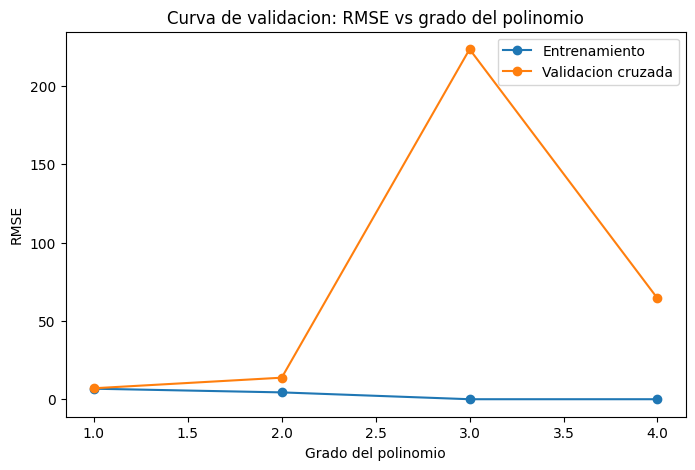

In [12]:
grados = [1, 2, 3, 4]

train_scores, val_scores = validation_curve(
    pipeline_polinomial, X_train, y_train,
    param_name='preparacion__numericas__polynomial__degree',
    param_range=grados,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rmse_train_grados = -train_scores.mean(axis=1)
rmse_val_grados = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(grados, rmse_train_grados, marker='o', label='Entrenamiento')
plt.plot(grados, rmse_val_grados, marker='o', label='Validacion cruzada')
plt.xlabel('Grado del polinomio')
plt.ylabel('RMSE')
plt.title('Curva de validacion: RMSE vs grado del polinomio')
plt.legend()
plt.show()


La curva de entrenamiento baja de forma constante a medida que sube el grado, hasta casi llegar a cero: el modelo se ajusta cada vez mejor a los datos que ya conoce, lo cual es esperable con más términos disponibles. La curva de validación cruzada se mantiene parecida a la de entrenamiento en grado 1, empieza a separarse en grado 2, y en grado 3 se dispara a un RMSE por encima de 200 grados, un valor sin ningún sentido físico para una temperatura. En grado 4 baja un poco pero sigue siendo mucho peor que en grado 1 o 2.

El punto donde se evidencia el sobreajuste está entre el grado 2 y el grado 3: es ahí donde el modelo deja de aprender el patrón general de los datos y empieza a ajustarse a detalles específicos del conjunto de entrenamiento, produciendo coeficientes muy grandes que generan predicciones extremas en algunas particiones de validación. Esto coincide con lo que ya habíamos encontrado con GridSearchCV, que descartó cualquier grado mayor a 1 por no generalizar bien en promedio.

## 6. Modelo de regresión Ridge (L2)

TODO:
- Construir un pipeline `pipeline_ridge` con `Ridge()` como modelo, reutilizando `limpiador`, `preparacion_categorica` y una preparación numérica con imputación + escalador (sin `PolynomialFeatures`), siguiendo el mismo esqueleto que `pipeline_polinomial` de la sección 4.
- Definir `param_grid_ridge` explorando varios valores de `alpha` (por ejemplo en escala logarítmica: 0.1, 1, 10, 100) y distintos escaladores (StandardScaler, MinMaxScaler, RobustScaler), igual que se hizo en la sección 4.
- Correr `GridSearchCV` con `cv=5` y guardar el mejor modelo en `best_ridge`.
- Calcular RMSE, MAE y R² de `best_ridge` en entrenamiento y en prueba.
- Extraer los coeficientes del mejor modelo (usando `get_feature_names_out()` del preprocesador, como en el Lab 1) y comentar cuáles tienen más peso.

In [ ]:
# TODO: pipeline_ridge, param_grid_ridge, GridSearchCV, best_ridge


## 7. Modelo de regresión Lasso (L1)


TODO:
- Construir `pipeline_lasso` igual que `pipeline_ridge` pero con `Lasso(max_iter=5000)` (el `max_iter` alto evita advertencias de convergencia).
- Definir `param_grid_lasso` con varios valores de `alpha` y los mismos escaladores.
- Correr `GridSearchCV` y guardar el mejor modelo en `best_lasso`.
- Calcular RMSE, MAE y R² en entrenamiento y prueba.
- Extraer los coeficientes y revisar cuáles quedaron en cero (o muy cerca de cero). Esto es lo importante de Lasso: identificar qué variables el modelo decidió descartar, y comentar qué significa eso en términos de selección automática de variables e interpretabilidad (por ejemplo, si descarta alguna de las variables de presión que ya sabíamos que estaban correlacionadas entre sí en el Lab 1).

In [ ]:
# TODO: pipeline_lasso, param_grid_lasso, GridSearchCV, best_lasso, revisar coeficientes en cero


## 8. Regresión polinomial regularizada

Se combina la generación de características polinomiales con un modelo regularizado (Ridge), para ver si la penalización permite aprovechar más complejidad sin que el modelo se sobreajuste tanto como en la sección 4.

In [13]:
preparacion_numerica_poly_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2))
])

preprocesador_poly_reg = ColumnTransformer(transformers=[
    ('numericas', preparacion_numerica_poly_reg, columnas_numericas),
    ('categoricas', preparacion_categorica, columnas_categoricas)
])

pipeline_polinomial_reg = Pipeline(steps=[
    ('limpieza', limpiador),
    ('preparacion', preprocesador_poly_reg),
    ('modelo', Ridge())
])



In [14]:
param_grid_poly_reg = {
    'preparacion__numericas__polynomial__degree': [1, 2, 3, 4],
    'modelo__alpha': [0.1, 1, 10, 100],
    'preparacion__numericas__scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()]
}

grid_poly_reg = GridSearchCV(
    estimator=pipeline_polinomial_reg,
    param_grid=param_grid_poly_reg,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_poly_reg.fit(X_train, y_train)

print('Mejor configuracion:', grid_poly_reg.best_params_)


Mejor configuracion: {'modelo__alpha': 10, 'preparacion__numericas__polynomial__degree': 4, 'preparacion__numericas__scaler': MinMaxScaler()}


In [15]:
mejor_modelo_poly_reg = grid_poly_reg.best_estimator_

pred_train_poly_reg = mejor_modelo_poly_reg.predict(X_train)
pred_test_poly_reg = mejor_modelo_poly_reg.predict(X_test)

print('Polinomial regularizado (Ridge) - Entrenamiento')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, pred_train_poly_reg)):.3f}")
print(f"MAE: {mean_absolute_error(y_train, pred_train_poly_reg):.3f}")
print(f"R2: {r2_score(y_train, pred_train_poly_reg):.3f}")

print('Polinomial regularizado (Ridge) - Prueba')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_test_poly_reg)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, pred_test_poly_reg):.3f}")
print(f"R2: {r2_score(y_test, pred_test_poly_reg):.3f}")


Polinomial regularizado (Ridge) - Entrenamiento
RMSE: 4.465
MAE: 3.282
R2: 0.765
Polinomial regularizado (Ridge) - Prueba
RMSE: 5.143
MAE: 3.788
R2: 0.691


Este es el mejor resultado de los que hemos construido hasta ahora. En prueba, el RMSE bajó a 5.143 grados, el MAE a 3.788 grados, y el R2 subió a 0.691, mejor que el polinomial sin regularizar (RMSE 5.817, MAE 4.254, R2 0.605) y mucho mejor que el modelo lineal simple del Lab 1 (RMSE 6.735, MAE 5.238, R2 0.470).

Lo más importante es cómo se logró esto: sin regularización, cualquier grado mayor a 1 hacía que el modelo se disparara (lo vimos en la curva de validación de la sección 5). Con Ridge, GridSearchCV pudo elegir grado 4, el más complejo que le dimos a escoger, porque la penalización evita que los coeficientes crezcan sin control. Además la brecha entre entrenamiento y prueba es más chica que en el polinomial sin regularizar: aquí es de 4.465 a 5.143 (0.68 grados), mientras que en el polinomial de grado 2 sin regularizar era de 4.495 a 5.817 (1.32 grados). Esto confirma que la regularización sí está cumpliendo su función: dejar que el modelo use relaciones no lineales más complejas sin perder tanta capacidad de generalizar.

In [17]:
nombres_columnas_reg = mejor_modelo_poly_reg.named_steps['preparacion'].get_feature_names_out()
coeficientes_reg = mejor_modelo_poly_reg.named_steps['modelo'].coef_

importancia_reg = pd.DataFrame({
    'variable': nombres_columnas_reg,
    'coeficiente': coeficientes_reg
})
importancia_reg['abs_coeficiente'] = importancia_reg['coeficiente'].abs()
importancia_reg = importancia_reg.sort_values('abs_coeficiente', ascending=False)

print('Coeficiente maximo (valor absoluto):', importancia_reg['abs_coeficiente'].max())
print('Coeficiente promedio (valor absoluto):', importancia_reg['abs_coeficiente'].mean())
importancia_reg.head(10)

Coeficiente maximo (valor absoluto): 5.327912566611764
Coeficiente promedio (valor absoluto): 0.11033941395784054


,variable,coeficiente,abs_coeficiente
14949,numericas__dia_del_anio^4,-5.327913,5.327913
14944,numericas__registros_del_dia dia_del_anio^3,-3.879377,3.879377
11889,numericas__humedad_max dia_del_anio^3,-3.690071,3.690071
2299,numericas__dia_del_anio^3,-3.668970,3.668970
6094,numericas__presion_min dia_del_anio^3,-3.386662,3.386662
22,numericas__dia_del_anio,3.302633,3.302633
14879,numericas__viento_norte dia_del_anio^3,-3.279515,3.279515
4323,numericas__presion_media dia_del_anio^3,-2.964033,2.964033
272,numericas__registros_del_dia dia_del_anio,2.902502,2.902502
2292,numericas__registros_del_dia^2 dia_del_anio,2.864602,2.864602


El coeficiente más grande de este modelo es 5.33, y el promedio de todos (en valor absoluto) es apenas 0.11. Son valores parecidos en escala a los que vimos en el Lab 1 con la regresión lineal simple, donde el coeficiente más grande era 4.36. Esto es notable porque este modelo tiene grado 4 y cientos de términos, y sin embargo ningún coeficiente se disparó, a diferencia de lo que hubiera pasado sin regularización (donde el RMSE llegó a más de 200 en la sección 5, lo que solo se explica con coeficientes muchísimo más grandes). Esa es exactamente la función de Ridge: mantener los coeficientes en un rango razonable aunque el modelo tenga muchos términos disponibles.

Las variables con más peso están casi todas relacionadas con `dia_del_anio` elevado a distintas potencias o combinado con otras variables. Tiene sentido que el día del año siga siendo importante, ya que en el Lab 1 vimos que la temperatura sigue un patrón estacional claro, pero como esta variable es cíclica (el día 365 está pegado al día 1) y aquí se está usando de forma polinomial, el modelo probablemente sigue sin capturar bien esa continuidad entre diciembre y enero.

## 9. Tabla comparativa de resultados

TODO:
- Armar una tabla (un DataFrame) que reúna, para cada modelo (polinomial, Ridge, Lasso, polinomial regularizado), el RMSE, MAE y R² en test, además del promedio y la desviación estándar del RMSE obtenidos por validación cruzada (usando `cross_val_score` sobre el mejor estimador de cada `GridSearchCV`).
- Reportar los mejores hiperparámetros encontrados para cada modelo.
- Elegir el modelo final considerando no solo el promedio de la métrica principal, sino también su estabilidad (desviación estándar), y justificar la elección por escrito.

In [ ]:
# TODO: tabla comparativa con RMSE/MAE/R2 en test + promedio y desviacion estandar de cross_val_score


## 10. Intervalos de confianza (bootstrapping)


TODO:
- Usando el modelo final seleccionado en la sección 9, aplicar bootstrapping sobre el conjunto de prueba con al menos 500 remuestreos (siguiendo el mismo patrón usado en las prácticas P5 y P6: `resample` sobre `X_test, y_test`, calcular el RMSE en cada remuestreo y guardar los valores).
- Calcular el intervalo de confianza al 95% con los percentiles 2.5 y 97.5 de esa distribución.
- Graficar el histograma de los RMSE obtenidos, marcando el promedio y los límites del intervalo.
- Repetir el mismo procedimiento para MAE y R² si alcanza el tiempo (pedido explícitamente en la rúbrica: intervalos de confianza para las métricas de desempeño, no solo RMSE).
- Escribir una conclusión corta sobre qué tan estable parece el modelo según el ancho del intervalo.

In [ ]:
# TODO: bootstrapping (>=500 remuestreos) sobre el modelo final, intervalo de confianza 95%, histograma


## 11. Análisis de resultados

### Análisis cuantitativo

### ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

Por ahora, entre los modelos ya construidos (lineal simple, polinomial y polinomial regularizado), el mejor es el polinomial regularizado con Ridge, con RMSE 5.143°C, MAE 3.788°C y R2 0.691 en prueba.

#TODO

### ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?

No coincide. En la sección 4, al probar el grado 2 a mano, obtuvimos mejor RMSE en el conjunto de test (5.817°C) que con el modelo lineal simple (6.735°C). Sin embargo, cuando se buscó el mejor grado con GridSearchCV, usando el promedio de 5 particiones de validación cruzada, el resultado fue que el grado 1 (equivalente al modelo lineal) generalizaba mejor en promedio que el grado 2.

La explicación está en que son dos formas distintas de medir el desempeño. El RMSE de test se calcula sobre una sola partición fija de los datos, así que puede verse afectado por cómo cayeron los datos en esa partición particular. La validación cruzada promedia el desempeño sobre 5 particiones distintas, lo que da una estimación más estable de qué tan bien generalizaría el modelo con datos nuevos. Es probable que el grado 2 haya tenido suerte en la partición de test que usamos, pero en promedio, sobre distintas particiones, no fuera consistentemente mejor que el modelo simple.

### ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.

#TODO

### Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?

El RMSE de entrenamiento baja de forma constante a medida que sube el grado del polinomio, hasta casi llegar a cero, porque el modelo cada vez se ajusta mejor a los datos que ya conoce. El RMSE de validación cruzada se comporta distinto: se mantiene parecido al de entrenamiento en grado 1, empieza a separarse en grado 2, y en grado 3 se dispara a más de 200°C, un valor sin sentido físico para una temperatura. En grado 4 baja un poco pero sigue siendo mucho peor que en grado 1 o 2.

El sobreajuste se evidencia entre el grado 2 y el grado 3. Es ahí donde el modelo deja de aprender el patrón general de los datos y empieza a ajustarse a detalles específicos del conjunto de entrenamiento, generando coeficientes tan grandes que producen predicciones extremas en algunas particiones de validación.

### ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

Con base en el modelo polinomial regularizado (sección 8), la regularización mantiene los coeficientes en un rango pequeño incluso cuando el modelo tiene grado 4 y cientos de términos: el coeficiente más grande es 5.33 y el promedio es apenas 0.11, valores parecidos en escala a los del modelo lineal simple del Lab 1 (coeficiente más grande de 4.36). Esto contrasta con lo que hubiera pasado sin regularización, donde ya en grado 3 el RMSE llegó a más de 200°C, algo que solo se explica con coeficientes mucho más grandes y descontrolados.

#TODO

### ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?

#TODO

### Análisis cualitativo

### ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?

#TODO

### ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?

#TODO

### ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

#TODO

### ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?

#TODO

### ¿Mayor precisión implica necesariamente mayor valor para la organización?

#TODO

### ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.

#TODO

### Reflexión conceptual

### ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?

#TODO

### ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

#TODO

### Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explica la respuesta.

#TODO

## Uso de herramientas de IA generativa

### Declaración de uso

Para este laboratorio se utilizó Claude (Anthropic), un asistente de inteligencia artificial generativa basado en modelos de lenguaje, principalmente como apoyo para revisar el trabajo realizado durante las diferentes etapas del notebook. El desarrollo del código, los procedimientos y el análisis se realizaron a lo largo del laboratorio y, al finalizar cada etapa, Claude se utilizó como herramienta de revisión para identificar posibles errores o inconsistencias, aclarar dudas conceptuales y revisar la redacción, gramática y claridad de las respuestas.

### Prompts principales

Se le pidió a la herramienta, entre otras cosas: revisar el código implementado e identificar posibles errores o inconsistencias, verificar si los procedimientos utilizados eran coherentes con lo visto en las prácticas del curso, aclarar dudas sobre conceptos como Pipeline, ColumnTransformer, GridSearchCV y validación cruzada, y revisar la redacción de las interpretaciones de los resultados para mejorar su claridad y corrección gramatical.

### Análisis crítico

Lo más útil fue utilizar Claude como una segunda revisión de los procedimientos y resultados obtenidos. En particular, permitió aclarar dudas sobre por qué GridSearchCV puede seleccionar un modelo diferente al que presenta mejores resultados sobre una sola partición de test y contrastar esta explicación con los conceptos vistos en clase y en las prácticas P5 y P6. También permitió identificar algunos aspectos del código que requerían ser revisados y detectar errores de redacción o gramática en las respuestas del análisis. Las sugerencias proporcionadas por la herramienta se utilizaron como apoyo para verificar el trabajo y se contrastaron con los resultados obtenidos y el material de clase.

### Aportes propios del estudiante

La mayor parte del desarrollo del laboratorio correspondió a la implementación del código, la ejecución de los procedimientos, la obtención de los resultados y el análisis de estos. Claude se utilizó posteriormente como apoyo de revisión en cada etapa, principalmente para detectar posibles errores, aclarar dudas puntuales y revisar la redacción y gramática de las respuestas. A partir de estas revisiones se realizaron las correcciones necesarias en el código, cuando correspondía, y en la redacción de las respuestas, manteniendo como referencia los resultados obtenidos y los conceptos trabajados en clase.
